## Import các thư viện cần thiết

In [1]:
import os
import json
import time
import random
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as F

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

from tqdm.auto import tqdm

In [2]:
# Thiết lập device
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

# Định nghĩa tên các lớp
CLASS_NAMES = [
    "apple", "tangerine", "pear", "watermelon", "durian",
    "lemon", "grape", "pineapple", "dragon fruit", "korean melon", "cantaloupe"
]
NUM_ACTUAL_CLASSES = len(CLASS_NAMES)
NUM_MODEL_CLASSES = NUM_ACTUAL_CLASSES + 1 # Bao gồm cả background

# Đường dẫn cơ sở
BASE_DATA_DIR = './fruit_object_detection' # Thay đổi nếu cần
ANNOTATIONS_DIR = os.path.join(BASE_DATA_DIR, 'annotations')

Using device: cuda


## Chuyển đổi Định dạng YOLO sang COCO

In [3]:
def convert_yolo_to_coco_split(dataset_path, split_name, output_file, class_names):
    """Chuyển đổi một split cụ thể (train/validation/test) từ YOLO sang COCO format."""
    coco_output = {
        "images": [],
        "annotations": [],
        "categories": []
    }

    # Tạo categories
    for i, name in enumerate(class_names):
        coco_output["categories"].append({
            "id": i,  # category_id từ 0 đến N-1
            "name": name,
            "supercategory": "fruit"
        })

    images_dir = os.path.join(dataset_path, split_name, "images")
    labels_dir = os.path.join(dataset_path, split_name, "labels")

    if not os.path.exists(images_dir):
        print(f"Thư mục hình ảnh không tồn tại: {images_dir}")
        return
    if not os.path.exists(labels_dir):
        print(f"Thư mục nhãn không tồn tại: {labels_dir}")
        return

    annotation_id_counter = 1
    image_id_counter = 1

    image_files = sorted([f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

    for img_file in tqdm(image_files, desc=f"Converting {split_name}"):
        img_path = os.path.join(images_dir, img_file)
        try:
            with Image.open(img_path) as img:
                img_width, img_height = img.size
        except IOError:
            print(f"Không thể mở hoặc đọc file ảnh: {img_path}")
            continue

        coco_output["images"].append({
            "id": image_id_counter,
            "file_name": img_file,
            "width": img_width,
            "height": img_height
        })

        label_file_base = os.path.splitext(img_file)[0]
        label_path = os.path.join(labels_dir, f"{label_file_base}.txt")

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        class_id, x_center, y_center, width, height = map(float, parts)
                        
                        # Chuyển đổi YOLO (normalized, center_x, center_y, w, h)
                        # sang COCO (absolute, x_min, y_min, w, h)
                        abs_x_center = x_center * img_width
                        abs_y_center = y_center * img_height
                        abs_width = width * img_width
                        abs_height = height * img_height
                        
                        x_min = abs_x_center - (abs_width / 2)
                        y_min = abs_y_center - (abs_height / 2)
                        
                        coco_output["annotations"].append({
                            "id": annotation_id_counter,
                            "image_id": image_id_counter,
                            "category_id": int(class_id), # Giữ nguyên class_id từ YOLO (0-10)
                            "bbox": [x_min, y_min, abs_width, abs_height],
                            "area": abs_width * abs_height,
                            "iscrowd": 0
                        })
                        annotation_id_counter += 1
        image_id_counter += 1
    
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    with open(output_file, 'w') as f:
        json.dump(coco_output, f, indent=2)
    
    print(f"Đã chuyển đổi {split_name}: {len(coco_output['images'])} ảnh, {len(coco_output['annotations'])} annotations.")
    print(f"Lưu vào: {output_file}")

# Chạy chuyển đổi
print("Bắt đầu chuyển đổi dataset sang COCO format...")
convert_yolo_to_coco_split(BASE_DATA_DIR, "train", os.path.join(ANNOTATIONS_DIR, "train_annotations.json"), CLASS_NAMES)
convert_yolo_to_coco_split(BASE_DATA_DIR, "validation", os.path.join(ANNOTATIONS_DIR, "validation_annotations.json"), CLASS_NAMES)
convert_yolo_to_coco_split(BASE_DATA_DIR, "test", os.path.join(ANNOTATIONS_DIR, "test_annotations.json"), CLASS_NAMES)
print("Hoàn tất chuyển đổi.")

# Đường dẫn file annotations
TRAIN_ANNOTATIONS_FILE = os.path.join(ANNOTATIONS_DIR, "train_annotations.json")
VAL_ANNOTATIONS_FILE = os.path.join(ANNOTATIONS_DIR, "validation_annotations.json")
TEST_ANNOTATIONS_FILE = os.path.join(ANNOTATIONS_DIR, "test_annotations.json")

# Đường dẫn thư mục ảnh
TRAIN_IMG_DIR = os.path.join(BASE_DATA_DIR, "train", "images")
VAL_IMG_DIR = os.path.join(BASE_DATA_DIR, "validation", "images")
TEST_IMG_DIR = os.path.join(BASE_DATA_DIR, "test", "images")

Bắt đầu chuyển đổi dataset sang COCO format...


Converting train:   0%|          | 0/3076 [00:00<?, ?it/s]

Đã chuyển đổi train: 3076 ảnh, 16146 annotations.
Lưu vào: ./fruit_object_detection\annotations\train_annotations.json


Converting validation:   0%|          | 0/769 [00:00<?, ?it/s]

Đã chuyển đổi validation: 769 ảnh, 4131 annotations.
Lưu vào: ./fruit_object_detection\annotations\validation_annotations.json


Converting test:   0%|          | 0/640 [00:00<?, ?it/s]

Đã chuyển đổi test: 640 ảnh, 2428 annotations.
Lưu vào: ./fruit_object_detection\annotations\test_annotations.json
Hoàn tất chuyển đổi.


In [3]:
# Đường dẫn file annotations
TRAIN_ANNOTATIONS_FILE = os.path.join(ANNOTATIONS_DIR, "train_annotations.json")
VAL_ANNOTATIONS_FILE = os.path.join(ANNOTATIONS_DIR, "validation_annotations.json")
TEST_ANNOTATIONS_FILE = os.path.join(ANNOTATIONS_DIR, "test_annotations.json")

# Đường dẫn thư mục ảnh
TRAIN_IMG_DIR = os.path.join(BASE_DATA_DIR, "train", "images")
VAL_IMG_DIR = os.path.join(BASE_DATA_DIR, "validation", "images")
TEST_IMG_DIR = os.path.join(BASE_DATA_DIR, "test", "images")

## Xây dựng Custom Dataset Class

In [4]:
class FruitDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None):
        """
        Custom Dataset cho fruit object detection
        
        Args:
            annotations_file (str): Đường dẫn đến file COCO json annotations
            img_dir (str): Thư mục chứa ảnh
            transform (callable, optional): Transform để áp dụng lên ảnh và bboxes
        """
        self.img_dir = img_dir
        self.transform = transform
        
        if not os.path.exists(annotations_file):
            raise FileNotFoundError(f"Annotation file not found: {annotations_file}")
        if not os.path.exists(img_dir):
            raise NotADirectoryError(f"Image directory not found: {img_dir}")
            
        self.coco = COCO(annotations_file)
        self.ids = list(sorted(self.coco.imgs.keys())) # Lấy image ids
        
        # Lấy danh sách categories từ file JSON (id: 0-10)
        self.coco_categories = self.coco.loadCats(self.coco.getCatIds())
        self.coco_cat_id_to_name = {cat["id"]: cat["name"] for cat in self.coco_categories}
        
        print(f"Loaded {len(self.ids)} images from {annotations_file}.")
        # print(f"COCO Categories (from JSON): {self.coco_cat_id_to_name}")

    def __len__(self):
        return len(self.ids)
    
    def __getitem__(self, index):
        img_id = self.ids[index]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        annotations = self.coco.loadAnns(ann_ids)
        
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        image = Image.open(img_path).convert("RGB")
        
        boxes = []
        labels = []
        areas = []
        iscrowd = []
        
        for ann in annotations:
            # COCO format: [x_min, y_min, width, height]
            # Chuyển sang [x1, y1, x2, y2] cho PyTorch
            x_min, y_min, width, height = ann['bbox']
            x1 = x_min
            y1 = y_min
            x2 = x_min + width
            y2 = y_min + height
            
            boxes.append([x1, y1, x2, y2])
            # QUAN TRỌNG: category_id từ file JSON (0-10) được +1 để thành nhãn cho model (1-11)
            # Model sẽ coi nhãn 0 là background.
            labels.append(ann['category_id'] + 1) 
            areas.append(ann['area'])
            iscrowd.append(ann.get('iscrowd', 0))

        # Chuyển đổi sang tensor
        if len(boxes) > 0:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            areas = torch.as_tensor(areas, dtype=torch.float32)
            iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)
        else: # Trường hợp không có object nào trong ảnh
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros(0, dtype=torch.int64)
            areas = torch.zeros(0, dtype=torch.float32)
            iscrowd = torch.zeros(0, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([img_id]),
            "area": areas,
            "iscrowd": iscrowd
        }
        
        if self.transform:
            image, target = self.transform(image, target)
        
        return image, target

## Thiết lập Transforms và DataLoader

In [5]:
class Compose:
    def __init__(self, transforms):
        self.transforms = transforms
    def __call__(self, image, target):
        for t in self.transforms:
            image, target = t(image, target)
        return image, target

class ToTensor:
    def __call__(self, image, target):
        image = F.to_tensor(image)
        return image, target

class RandomHorizontalFlip:
    def __init__(self, prob=0.5):
        self.prob = prob
    def __call__(self, image, target):
        if random.random() < self.prob:
            height, width = image.shape[-2:]
            image = image.flip(-1)
            bbox = target["boxes"]
            if bbox.shape[0] > 0: # Chỉ flip nếu có box
                 bbox[:, [0, 2]] = width - bbox[:, [2, 0]]
                 target["boxes"] = bbox
        return image, target

def get_transform(train):
    transforms = [ToTensor()]
    if train:
        transforms.append(RandomHorizontalFlip(0.5))
    return Compose(transforms)

def collate_fn(batch):
    return tuple(zip(*batch))

# Tạo datasets
print("\nĐang tạo datasets...")
train_dataset = FruitDataset(TRAIN_ANNOTATIONS_FILE, TRAIN_IMG_DIR, transform=get_transform(train=True))
val_dataset = FruitDataset(VAL_ANNOTATIONS_FILE, VAL_IMG_DIR, transform=get_transform(train=False))
test_dataset = FruitDataset(TEST_ANNOTATIONS_FILE, TEST_IMG_DIR, transform=get_transform(train=False))
print("Hoàn tất tạo datasets.")

# Tạo DataLoaders
BATCH_SIZE = 4 # Giảm nếu gặp lỗi Out of Memory (OOM)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=2, pin_memory=True if device.type == 'cuda' else False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=True if device.type == 'cuda' else False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=True if device.type == 'cuda' else False)
print(f"Số lượng batch trong train_loader: {len(train_loader)}")
print(f"Số lượng batch trong val_loader: {len(val_loader)}")
print(f"Số lượng batch trong test_loader: {len(test_loader)}")


Đang tạo datasets...
loading annotations into memory...
Done (t=0.08s)
creating index...
index created!
Loaded 3076 images from ./fruit_object_detection\annotations\train_annotations.json.
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
Loaded 769 images from ./fruit_object_detection\annotations\validation_annotations.json.
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Loaded 640 images from ./fruit_object_detection\annotations\test_annotations.json.
Hoàn tất tạo datasets.
Số lượng batch trong train_loader: 769
Số lượng batch trong val_loader: 193
Số lượng batch trong test_loader: 160


## Khởi tạo Model

In [ ]:
def build_model(num_model_classes):
    """
    Xây dựng model Faster R-CNN.
    
    Args:
        num_model_classes (int): Số lượng classes (bao gồm background).
        
    Returns:
        model: Model Faster R-CNN.
    """
    # Khởi tạo model Faster R-CNN với backbone ResNet50 + FPN
    model = fasterrcnn_resnet50_fpn(weights='DEFAULT')

    # Lấy số features đầu vào của lớp phân loại hiện tại
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    
    # Thay thế box predictor để khớp với số lớp của bài toán
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_model_classes)
    
    return model

print("\nĐang khởi tạo model...")
model = build_model(NUM_MODEL_CLASSES) # 11 loại quả + 1 background
model.to(device)
print("Hoàn tất khởi tạo model.")


Đang khởi tạo model...
Hoàn tất khởi tạo model.


## Training Loop với Early Stopping

In [ ]:
def train_one_epoch(model, optimizer, data_loader, device, epoch_num, total_epochs):
    """
    Huấn luyện model trong một epoch và tính toán training loss và training mAP.
    
    Args:
        model: Model Faster R-CNN.
        optimizer: Optimizer (ví dụ Adam).
        data_loader: DataLoader cho tập train.
        device: 'cuda' hoặc 'cpu'.
        epoch_num (int): Số thứ tự epoch hiện tại (để hiển thị).
        total_epochs (int): Tổng số epochs (để hiển thị).
        
    Returns:
        tuple: (avg_train_loss, train_mAP)
    """
    model.train() # Đặt model ở chế độ training
    
    total_loss = 0
    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch_num+1}/{total_epochs} [Training]")
    

    for images, targets in progress_bar:
        images = [image.to(device) for image in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        # Forward pass và tính loss
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        """loss_dict = {
                'loss_classifier': ...,  # Detector Classification Loss
                'loss_box_reg': ...,     # Detector Bounding Box Regression Loss
                'loss_objectness': ...,  # RPN Classification Loss
                'loss_rpn_box_reg': ...  # RPN Bounding Box Regression Loss
            }"""
        
        # Backpropagation
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        
        total_loss += losses.item()
        progress_bar.set_postfix(train_loss=losses.item())

    avg_train_loss = total_loss / len(data_loader)
    
    return avg_train_loss


def evaluate(model, data_loader, device, epoch_num=None, total_epochs=None):
    """
    Đánh giá model trên tập dữ liệu (validation/test), tính loss và mAP.
    
    Args:
        model: Model Faster R-CNN.
        data_loader: DataLoader cho tập validation hoặc test.
        device: 'cuda' hoặc 'cpu'.
        epoch_num (int, optional): Epoch hiện tại, dùng cho mô tả của tqdm.
        total_epochs (int, optional): Tổng số epoch, dùng cho mô tả của tqdm.
        
    Returns:
        tuple: (avg_val_loss, val_mAP)
               val_mAP là mAP@[.5:.95]
    """
    coco_gt = data_loader.dataset.coco # Ground truth COCO object
    predictions_for_map = []
    image_ids_for_map = []
    
    # --- Phần 1: Tính Validation Loss ---
    # Tạm chuyển model sang train() mode để lấy loss_dict, nhưng không backprop
    model.train() 
    total_val_loss = 0
    
    desc_str_loss = "Evaluating Loss"
    if epoch_num is not None and total_epochs is not None:
        desc_str_loss = f"Epoch {epoch_num+1}/{total_epochs} [Val Loss]"

    with torch.no_grad(): # Quan trọng: không tính gradient khi đang eval loss
        for images, targets in tqdm(data_loader, desc=desc_str_loss, leave=False):
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            loss_dict = model(images, targets) # Model ở train mode sẽ trả về loss
            losses = sum(loss for loss in loss_dict.values())
            total_val_loss += losses.item()
    
    avg_val_loss = total_val_loss / len(data_loader) if len(data_loader) > 0 else 0.0

    # --- Phần 2: Tính mAP ---
    model.eval() # Chuyển model sang eval() mode để lấy predictions
    
    desc_str_map = "Evaluating mAP"
    if epoch_num is not None and total_epochs is not None:
        desc_str_map = f"Epoch {epoch_num+1}/{total_epochs} [Val mAP]"

    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc=desc_str_map, leave=False):
            images = [img.to(device) for img in images]
            # Không cần targets cho prediction, nhưng lấy image_id từ targets
            
            preds = model(images) # Model ở eval mode sẽ trả về predictions
            
            for i, pred in enumerate(preds):
                # image_id thực sự từ target (do model không trả về image_id)
                img_id = targets[i]['image_id'].item() 
                image_ids_for_map.append(img_id)
                
                # Lấy boxes, scores, labels từ prediction
                # boxes đã ở dạng [x1, y1, x2, y2]
                boxes = pred['boxes'].cpu().numpy()
                scores = pred['scores'].cpu().numpy()
                labels = pred['labels'].cpu().numpy() # Nhãn từ model là 1-11

                for box, score, label in zip(boxes, scores, labels):
                    # Chỉ lấy các dự đoán có score > ngưỡng nhỏ (COCOeval sẽ xử lý sau)
                    if score > 0.01: # Ngưỡng này có thể cần điều chỉnh
                        x1, y1, x2, y2 = box
                        # Chuyển label từ 1-11 về 0-10 cho COCOeval
                        # vì category_id trong coco_gt là 0-10
                        coco_label = label.item() - 1 
                        
                        predictions_for_map.append({
                            "image_id": img_id,
                            "category_id": coco_label, 
                            "bbox": [x1, y1, x2 - x1, y2 - y1], # COCO format: [x, y, w, h]
                            "score": score.item(),
                        })
    
    val_mAP = 0.0
    if predictions_for_map:
        try:
            coco_dt = coco_gt.loadRes(predictions_for_map) # Load predictions
            coco_eval = COCOeval(coco_gt, coco_dt, 'bbox') # 'bbox' for bounding box evaluation
     
            img_ids_to_eval = list(set(image_ids_for_map))
            if not img_ids_to_eval: # Nếu không có ảnh nào có dự đoán
                 print("Cảnh báo: Không có dự đoán nào hợp lệ để tính mAP.")
            else:
                coco_eval.params.imgIds = img_ids_to_eval
                coco_eval.evaluate()
                coco_eval.accumulate()
                coco_eval.summarize() # In ra bảng kết quả chi tiết
                val_mAP = coco_eval.stats[0]  # mAP @ IoU=0.50:0.95 (primary COCO challenge metric)
        except Exception as e:
            print(f"Lỗi trong quá trình tính COCO mAP: {e}")
            print("predictions_for_map sample:", predictions_for_map[:5] if predictions_for_map else "None")
            val_mAP = 0.0 # Hoặc một giá trị lỗi khác
    else:
        print("Không có dự đoán nào được tạo ra để tính mAP.")
        
    return avg_val_loss, val_mAP

# Thiết lập training
print("\nBắt đầu quá trình huấn luyện...")
NUM_EPOCHS = 20
LEARNING_RATE = 0.0001

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(params, lr=LEARNING_RATE, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1) # Giảm LR sau mỗi 7 epochs

# Early Stopping
PATIENCE = 10 # Số epoch không cải thiện trước khi dừng
best_val_mAP = 0.0
epochs_no_improve = 0
best_model_path = "faster_rcnn_fruit_best.pth"

history = {'train_loss': [], 'val_loss': [], 'val_mAP': []}

for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()
    
    # Training
    train_loss = train_one_epoch(model, optimizer, train_loader, device, epoch, NUM_EPOCHS)
    
    # Validation
    val_loss, val_mAP = evaluate(model, val_loader, device, epoch, NUM_EPOCHS)
    
    epoch_time = time.time() - epoch_start_time
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Time: {epoch_time:.2f}s")
    # print(f"  Train Loss: {train_loss:.4f} | Train mAP: {current_train_mAP:.4f}") # Nếu tính train_mAP
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss: {val_loss:.4f} | Val mAP: {val_mAP:.4f}")
    
    history['train_loss'].append(train_loss)
    # history['train_mAP'].append(current_train_mAP) # Nếu tính train_mAP
    history['val_loss'].append(val_loss)
    history['val_mAP'].append(val_mAP)
    
    # Cập nhật learning rate
    lr_scheduler.step()
    
    # Early stopping và lưu model tốt nhất
    if val_mAP > best_val_mAP:
        best_val_mAP = val_mAP
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"  Validation mAP cải thiện. Model tốt nhất được lưu tại: {best_model_path}")
    else:
        epochs_no_improve += 1
        print(f"  Validation mAP không cải thiện. Số epoch không cải thiện: {epochs_no_improve}/{PATIENCE}")
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping tại epoch {epoch+1} do không có cải thiện mAP trên tập validation.")
            break
            
print(f"Hoàn tất huấn luyện! Model tốt nhất được lưu tại {best_model_path} với Val mAP: {best_val_mAP:.4f}")

# Vẽ biểu đồ loss và mAP
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.subplot(1, 2, 2)
plt.plot(history['val_mAP'], label='Validation mAP@[.5:.95]')
plt.xlabel('Epoch')
plt.ylabel('mAP')
plt.legend()
plt.title('mAP')
plt.tight_layout()
plt.show()

## Đánh giá Model trên Tập Validation và Test

In [ ]:
def calculate_iou(boxA, boxB): # Hàm này có vẻ ổn
    # ... (giữ nguyên) ...
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    # Thêm kiểm tra mẫu số khác 0
    denominator = float(boxAArea + boxBArea - interArea)
    if denominator == 0:
        return 0.0
    iou = interArea / denominator
    return iou


def evaluate_model_performance(model_to_eval, data_loader, device, dataset_name="Dataset", # Thêm model_to_eval
                                       conf_threshold_for_miou=0.5, iou_threshold_for_miou=0.5):
    print(f"\n--- Đánh giá tập trung trên tập {dataset_name} ---")
    
    coco_gt = data_loader.dataset.coco
    predictions_for_coco = []
    image_ids_for_coco = [] # Các image_id có dự đoán
    
    model_to_eval.eval() # Đảm bảo model ở chế độ eval
    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc=f"Collecting predictions for {dataset_name}", leave=False):
            images_device = [img.to(device) for img in images]
            try:
                preds = model_to_eval(images_device) # Sử dụng model_to_eval
                for i, pred_item in enumerate(preds):
                    # Đảm bảo targets[i] tồn tại và có 'image_id'
                    if i < len(targets) and 'image_id' in targets[i]:
                        img_id = targets[i]['image_id'].item() 
                        image_ids_for_coco.append(img_id)
                        
                        boxes = pred_item['boxes'].cpu().numpy()
                        scores = pred_item['scores'].cpu().numpy()
                        labels_pred = pred_item['labels'].cpu().numpy() # Model labels 1-11

                        for box, score, label_val in zip(boxes, scores, labels_pred):
                            if score > 0.01:
                                x1, y1, x2, y2 = box
                                coco_label = label_val.item() - 1 # Chuyển về 0-10 cho COCOeval
                                predictions_for_coco.append({
                                    "image_id": img_id,
                                    "category_id": coco_label, 
                                    "bbox": [x1, y1, x2 - x1, y2 - y1],
                                    "score": score.item(),
                                })
                    else:
                        print(f"Cảnh báo: Thiếu target hoặc image_id cho prediction index {i} trong batch.")
            except Exception as e:
                print(f"Lỗi khi lấy predictions cho batch: {e}")
                # Có thể thêm logging.error ở đây
                continue
    
    mAP_05_95 = 0.0
    AR_max100 = 0.0
    
    if not predictions_for_coco:
        print(f"Không có dự đoán nào (với score > 0.01) được tạo ra trên tập {dataset_name}.")
    else:
        print(f"Tổng số dự đoán thu thập được (score > 0.01): {len(predictions_for_coco)}")
        try:
            coco_dt = coco_gt.loadRes(predictions_for_coco)
            coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
            
            # Sử dụng các image_id có trong ground truth và cũng có trong dự đoán
            # Điều này quan trọng để COCOeval hoạt động đúng
            gt_img_ids = set(coco_gt.getImgIds())
            pred_img_ids = set(image_ids_for_coco)
            img_ids_to_eval = list(gt_img_ids.intersection(pred_img_ids))
            
            print(f"Số lượng image_id trong GT: {len(gt_img_ids)}")
            print(f"Số lượng image_id có dự đoán: {len(pred_img_ids)}")
            print(f"Số lượng image_id sẽ được đánh giá (giao của GT và Pred): {len(img_ids_to_eval)}")


            if not img_ids_to_eval:
                 print(f"Cảnh báo trên {dataset_name}: Không có image_id chung nào giữa GT và Predictions để đánh giá.")
            else:
                coco_eval.params.imgIds = img_ids_to_eval
                
                # In ra các category ID mà COCOeval sẽ sử dụng
                # Mặc định, nó sẽ lấy từ coco_gt. Nếu bạn muốn chỉ định, dùng coco_eval.params.catIds = [...]
                print(f"Category IDs COCOeval sẽ dùng (mặc định từ GT): {coco_eval.params.catIds}")

                coco_eval.evaluate()
                coco_eval.accumulate()
                
                print(f"\n--- COCOeval Summary cho {dataset_name} ---")
                coco_eval.summarize() # In bảng tóm tắt để kiểm tra

                mAP_05_95 = coco_eval.stats[0]
                AR_max100 = coco_eval.stats[8]
                
                print(f"\n1. mAP (IoU=.50:.05:.95) trên tập {dataset_name}: {mAP_05_95:.4f}")
                print(f"3. AR (maxDets=100, IoU=.50:.05:.95) trên tập {dataset_name}: {AR_max100:.4f}")

                print(f"\n2. Average Precision (AP) theo từng lớp (IoU=.50:.05:.95) cho {dataset_name}:")
                if hasattr(data_loader.dataset, 'coco_cat_id_to_name'):
                    cat_id_to_name = data_loader.dataset.coco_cat_id_to_name
                    
                    # Lấy danh sách catIds mà COCOeval thực sự đã đánh giá (sau accumulate)
                    # hoặc dùng coco_eval.params.catIds nếu bạn chắc chắn chúng được thiết lập đúng
                    evaluated_cat_ids_indices = range(len(coco_eval.params.catIds)) # Giả sử params.catIds là đúng

                    # Kiểm tra shape của mảng precision
                    print(f"Shape của coco_eval.eval['precision']: {coco_eval.eval['precision'].shape}")
                    # Shape là (T, R, K, A, M)
                    # T: num IoU thresholds (10)
                    # R: num Recall thresholds (101)
                    # K: num categories
                    # A: num Area ranges (4)
                    # M: num MaxDets (3)
                    num_categories_in_eval_precision = coco_eval.eval['precision'].shape[2]
                    
                    # Lặp qua các cat_idx dựa trên số lượng categories thực tế trong eval['precision']
                    # và map ngược lại cat_id gốc từ coco_eval.params.catIds
                    if num_categories_in_eval_precision != len(coco_eval.params.catIds):
                        print(f"Cảnh báo: Số lượng categories trong eval['precision'] ({num_categories_in_eval_precision}) không khớp với params.catIds ({len(coco_eval.params.catIds)}).")
                        # Có thể chỉ lặp qua min(num_categories_in_eval_precision, len(coco_eval.params.catIds))

                    for cat_idx in range(num_categories_in_eval_precision):
                        # Lấy cat_id tương ứng với cat_idx này từ params.catIds
                        # Cần đảm bảo cat_idx < len(coco_eval.params.catIds)
                        if cat_idx < len(coco_eval.params.catIds):
                            cat_id = coco_eval.params.catIds[cat_idx]
                            cat_name = cat_id_to_name.get(cat_id, f"UnknownCatID_{cat_id}")
                            
                            # ap_for_category = coco_eval.eval['precision'][:, :, cat_idx, 0, 2].mean()
                            # Đảm bảo rằng không có lỗi index ở đây
                            try:
                                ap_values_for_cat = coco_eval.eval['precision'][:, :, cat_idx, 0, 2]
                                # Loại bỏ các giá trị -1 (không có GT) trước khi tính mean
                                valid_ap_values = ap_values_for_cat[ap_values_for_cat > -1]
                                if valid_ap_values.size > 0:
                                    ap_for_category = valid_ap_values.mean()
                                else: # Không có GT hoặc không có dự đoán nào được đánh giá cho lớp này
                                    ap_for_category = -1 # Hoặc 0.0 nếu muốn
                            except IndexError:
                                print(f"Lỗi IndexError khi truy cập precision cho cat_idx {cat_idx}. Bỏ qua lớp này.")
                                continue # Bỏ qua lớp này nếu có lỗi


                            if ap_for_category == -1:
                                 print(f"  Lớp: {cat_name:<20} | AP: N/A (Không có GT hoặc dự đoán được đánh giá)")
                            else:
                                print(f"  Lớp: {cat_name:<20} | AP: {ap_for_category:.4f}")
                        else:
                            print(f"Cảnh báo: cat_idx {cat_idx} vượt quá độ dài của coco_eval.params.catIds.")
                else:
                    print("  Không thể lấy tên lớp, thuộc tính 'coco_cat_id_to_name' không tồn tại trong dataset.")
        except Exception as e:
            print(f"Lỗi trong quá trình chạy COCOeval trên {dataset_name}: {e}")
            import traceback
            traceback.print_exc() # In traceback đầy đủ
            print("  mAP và AR có thể không chính xác.")

    # Phần tính Mean IoU of matched boxes giữ nguyên
    # ... (code tính mIoU của bạn) ...
    all_pred_for_miou_calc = [] # Khởi tạo lại cho mỗi lần gọi hàm
    all_targets_for_miou_calc = []
    model_to_eval.eval()
    with torch.no_grad():
        for images, targets_batch in tqdm(data_loader, desc=f"Collecting preds for mIoU on {dataset_name}", leave=False):
            # ... (code thu thập dự đoán cho mIoU như cũ) ...
            images_device = [img.to(device) for img in images]
            try:
                preds_batch = model_to_eval(images_device)
                for i in range(len(preds_batch)):
                    if i < len(targets_batch): # Đảm bảo targets_batch[i] tồn tại
                        pred_boxes_raw = preds_batch[i]['boxes'].cpu().numpy()
                        pred_labels_raw = preds_batch[i]['labels'].cpu().numpy()
                        pred_scores_raw = preds_batch[i]['scores'].cpu().numpy()
                        
                        target_boxes_raw = targets_batch[i]['boxes'].cpu().numpy()
                        target_labels_raw = targets_batch[i]['labels'].cpu().numpy()
                        
                        keep_indices = pred_scores_raw >= conf_threshold_for_miou
                        
                        all_pred_for_miou_calc.append({
                            'boxes': pred_boxes_raw[keep_indices],
                            'labels': pred_labels_raw[keep_indices]
                        })
                        all_targets_for_miou_calc.append({
                            'boxes': target_boxes_raw,
                            'labels': target_labels_raw
                        })
                    else:
                        print(f"Cảnh báo: Thiếu target cho prediction index {i} trong batch khi tính mIoU.")
            except Exception as e:
                print(f"Lỗi khi lấy predictions cho mIoU, batch: {e}")
                continue # Bỏ qua batch nếu lỗi

    total_iou_sum_for_matches = 0
    matched_boxes_count = 0
    if all_pred_for_miou_calc: # Kiểm tra list không rỗng
        for i in range(len(all_pred_for_miou_calc)):
            # ... (code tính mIoU như cũ) ...
            pred_info = all_pred_for_miou_calc[i]
            target_info = all_targets_for_miou_calc[i]
            pred_boxes = pred_info['boxes']
            pred_labels = pred_info['labels']
            gt_boxes = target_info['boxes']
            gt_labels = target_info['labels']
            gt_matched_for_miou = [False] * len(gt_boxes)
            for j in range(len(pred_boxes)):
                pred_box_miou = pred_boxes[j]
                pred_label_miou = pred_labels[j]
                best_iou_val_miou = 0
                best_gt_idx_miou = -1
                for k in range(len(gt_boxes)):
                    if gt_labels[k] == pred_label_miou: 
                        iou_val_miou = calculate_iou(pred_box_miou, gt_boxes[k])
                        if iou_val_miou > best_iou_val_miou:
                            best_iou_val_miou = iou_val_miou
                            best_gt_idx_miou = k
                if best_iou_val_miou >= iou_threshold_for_miou and best_gt_idx_miou != -1 and not gt_matched_for_miou[best_gt_idx_miou]:
                    gt_matched_for_miou[best_gt_idx_miou] = True
                    total_iou_sum_for_matches += best_iou_val_miou
                    matched_boxes_count += 1
        
    mean_iou_of_matches = total_iou_sum_for_matches / matched_boxes_count if matched_boxes_count > 0 else 0.0
    print(f"\n4. Mean IoU of matched boxes trên tập {dataset_name} (conf_thresh={conf_threshold_for_miou}, iou_thresh={iou_threshold_for_miou}): {mean_iou_of_matches:.4f}")
    # ... (print còn lại) ...

# --- Phần gọi hàm đánh giá ---
# Đảm bảo BEST_MODEL_PATH đã được định nghĩa và model đã được train
BEST_MODEL_PATH = "/kaggle/input/model/faster_rcnn_fruit_best.pth" # Ví dụ
if os.path.exists(BEST_MODEL_PATH):
     print("\nĐang tải model tốt nhất để đánh giá...")
     model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
     model.to(device) # Đảm bảo model trên đúng device
     model.eval()

    # Đánh giá trên tập Validation
     evaluate_model_performance(model, val_loader, device, dataset_name="Validation")

    # Đánh giá trên tập Test
     evaluate_model_performance(model, test_loader, device, dataset_name="Test")
else:
     print(f"Không tìm thấy model đã lưu tại {BEST_MODEL_PATH} để đánh giá.")


Đang tải model tốt nhất để đánh giá...

--- Đánh giá tập trung trên tập Validation ---


## Demo

Đã phát hiện 6 đối tượng với confidence > 0.5


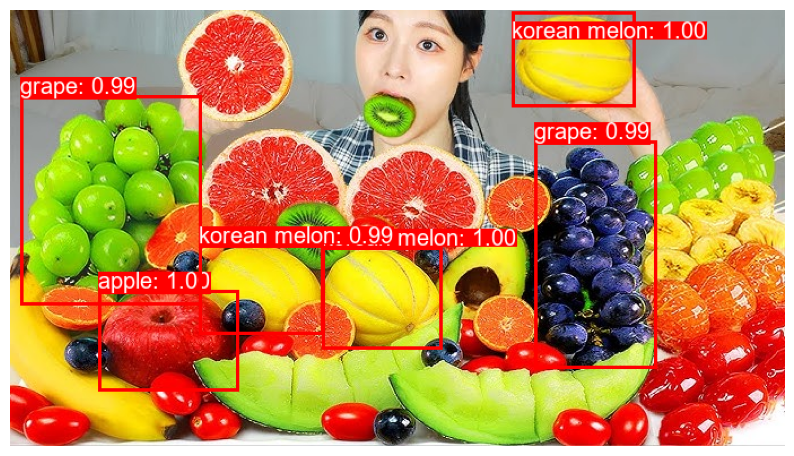

In [7]:
best_model_path = "faster_rcnn_fruit_best.pth"

def predict_single_image(model, image_path, device, class_names_map, conf_threshold=0.5):
    """
    Dự đoán trên một ảnh đơn, vẽ bounding box và hiển thị kết quả.
    
    Args:
        model: Model đã train.
        image_path (str): Đường dẫn đến ảnh.
        device: 'cuda' hoặc 'cpu'.
        class_names_map (dict): Map từ class_id (1-11) sang tên class.
        conf_threshold (float): Ngưỡng tin cậy để hiển thị dự đoán.
    """
    model.eval() # Đặt model ở chế độ đánh giá
    
    try:
        img_pil = Image.open(image_path).convert("RGB")
    except FileNotFoundError:
        print(f"Không tìm thấy ảnh tại: {image_path}")
        return
    except Exception as e:
        print(f"Lỗi khi mở ảnh: {e}")
        return

    # Transform ảnh (chỉ to_tensor, không augment)
    img_tensor = F.to_tensor(img_pil).to(device)
    
    with torch.no_grad():
        prediction = model([img_tensor]) # Model nhận list ảnh
        
    # Lấy kết quả dự đoán cho ảnh đầu tiên (và duy nhất)
    pred = prediction[0]
    
    # Chuẩn bị để vẽ
    draw = ImageDraw.Draw(img_pil)
    
    # Font (tùy chọn, có thể cần file font .ttf)
    try:
        font = ImageFont.truetype("arial.ttf", 20)
    except IOError:
        font = ImageFont.load_default()

    num_detections = 0
    for i in range(len(pred['scores'])):
        score = pred['scores'][i].item()
        if score > conf_threshold:
            num_detections +=1
            box = pred['boxes'][i].cpu().numpy().astype(int) # [x1, y1, x2, y2]
            label_id = pred['labels'][i].item() # Nhãn từ model (1-11)
            
            class_name = class_names_map.get(label_id, f"Unknown_ID_{label_id}")
            
            # Vẽ bounding box
            draw.rectangle([(box[0], box[1]), (box[2], box[3])], outline="red", width=3)
            
            # Viết tên class và score
            text = f"{class_name}: {score:.2f}"
            text_position = (box[0], box[1] - 20 if box[1] - 20 > 0 else box[1] + 5) # Để text không bị che
            
            # Tạo background cho text để dễ đọc hơn
            text_bbox = draw.textbbox(text_position, text, font=font)
            draw.rectangle(text_bbox, fill="red")
            draw.text(text_position, text, fill="white", font=font)
            
    print(f"Đã phát hiện {num_detections} đối tượng với confidence > {conf_threshold}")
    
    # Hiển thị ảnh
    plt.figure(figsize=(10, 8))
    plt.imshow(img_pil)
    plt.axis('off') # Tắt trục tọa độ
    plt.show()

# Tạo map từ ID model (1-11) sang tên lớp (CLASS_NAMES có index 0-10)
MODEL_ID_TO_NAME = {i+1: name for i, name in enumerate(CLASS_NAMES)}

# Ví dụ sử dụng (thay 'path/to/your/test_image.jpg' bằng đường dẫn thực tế)
# Bạn có thể chọn một ảnh từ tập test hoặc một ảnh hoàn toàn mới.
# Ví dụ lấy ảnh đầu tiên từ tập test
""" if len(test_dataset) > 0:
    first_test_img_info = test_dataset.coco.loadImgs(test_dataset.ids[5])[0]
    example_image_path = os.path.join(TEST_IMG_DIR, first_test_img_info['file_name'])
    print(f"\nSử dụng ảnh ví dụ: {example_image_path}")

    # Load lại model tốt nhất nếu chưa load
    if not os.path.exists(best_model_path):
        print(f"Không tìm thấy model đã lưu: {best_model_path}. Vui lòng train lại.")
    else:
        model.load_state_dict(torch.load(best_model_path, map_location=device))
        model.to(device)
        predict_single_image(model, example_image_path, device, MODEL_ID_TO_NAME, conf_threshold=0.5)
else:
    print("Tập test rỗng, không thể lấy ảnh ví dụ.") """

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
example_image_path = "hq720.jpg"
if os.path.exists(example_image_path):
    predict_single_image(model, example_image_path, device, MODEL_ID_TO_NAME, conf_threshold=0.5)
else:
    print(f"Ảnh tùy chỉnh không tìm thấy: {example_image_path}")